In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings 
warnings.filterwarnings("ignore")

In [48]:
df = pd.read_csv("Loan_default.csv")

In [49]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [50]:
df.shape

(255347, 18)

In [51]:
df.columns

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [53]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [54]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df = df.drop("LoanID", axis=1)

In [57]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')

In [58]:
df.select_dtypes(include='object').columns

Index(['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage',
       'HasDependents', 'LoanPurpose', 'HasCoSigner'],
      dtype='object')

In [59]:
for col in df.select_dtypes(include='object').columns:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(df[col].unique())


Column: Education
["Bachelor's" "Master's" 'High School' 'PhD']

Column: EmploymentType
['Full-time' 'Unemployed' 'Self-employed' 'Part-time']

Column: MaritalStatus
['Divorced' 'Married' 'Single']

Column: HasMortgage
['Yes' 'No']

Column: HasDependents
['Yes' 'No']

Column: LoanPurpose
['Other' 'Auto' 'Business' 'Home' 'Education']

Column: HasCoSigner
['Yes' 'No']


In [60]:
binary_columns = ['HasMortgage', 'HasDependents', 'HasCoSigner']

for col in binary_columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [61]:

df[['HasMortgage', 'HasDependents', 'HasCoSigner']].head()

,HasMortgage,HasDependents,HasCoSigner
0,1,1,1
1,0,0,1
2,1,1,0
3,0,0,0
4,0,1,0


In [62]:
df = pd.get_dummies(
    df,
    columns=['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose'],
    drop_first=True
)

In [63]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,False,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,False,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,False,False,False,True,False,False,False,False,False,False


In [64]:
X = df.drop("Default", axis=1)
y = df["Default"]

In [65]:
X.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,Education_PhD,EmploymentType_Part-time,EmploymentType_Self-employed,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,False,False,False,False,False,False,False,False,False,True
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,False,False,False,True,False,False,False,False,True
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,False,False,False,True,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,False,False,False,True,False,True,False,False,False
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,False,False,False,True,False,False,False,False,False,False


In [66]:
y.head()

0    0
1    0
2    1
3    0
4    0
Name: Default, dtype: int64

In [67]:
print(X.shape)
print(y.shape)

(255347, 24)
(255347,)


In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [69]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels  :", y_train.shape)
print("Testing Labels   :", y_test.shape)

Training Features: (204277, 24)
Testing Features : (51070, 24)
Training Labels  : (204277,)
Testing Labels   : (51070,)


In [70]:
from imblearn.over_sampling import SMOTE

In [71]:
smote = SMOTE(random_state=42)

In [72]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42, max_iter=1000)

In [73]:
lr_model.fit(X_train_smote, y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [74]:
y_pred = lr_model.predict(X_test)

In [75]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
print(confusion_matrix(y_test, y_pred))

[[38345  6794]
 [ 3959  1972]]


In [76]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.85      0.88     45139
           1       0.22      0.33      0.27      5931

    accuracy                           0.79     51070
   macro avg       0.57      0.59      0.57     51070
weighted avg       0.83      0.79      0.81     51070



In [77]:
y_prob = lr_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6655538597875807


In [85]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [86]:
y_pred_rf = rf_model.predict(X_test)

In [87]:
print(confusion_matrix(y_test, y_pred_rf))

[[43548  1591]
 [ 5208   723]]


In [88]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.96      0.93     45139
           1       0.31      0.12      0.18      5931

    accuracy                           0.87     51070
   macro avg       0.60      0.54      0.55     51070
weighted avg       0.83      0.87      0.84     51070



In [89]:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.7071941971155331


In [ ]:
# Conclusion

Two classification models were developed and evaluated for loan default prediction.

- Logistic Regression achieved better recall (0.33) and F1-score (0.27) for the minority class.
- Random Forest achieved higher overall accuracy (87%), better precision (0.31), and a higher ROC-AUC score (0.707).

Based on these evaluation metrics, Random Forest was selected as the final model because it demonstrated stronger overall predictive performance. Future work could include hyperparameter tuning and threshold optimization to improve recall for the minority class.

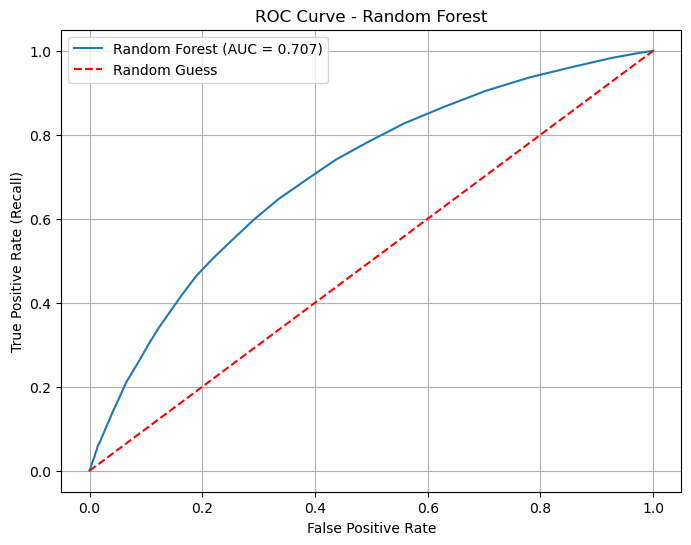

In [91]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='red', label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Random Forest")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## ROC Curve Analysis

The ROC Curve illustrates the relationship between the True Positive Rate (Recall) and the False Positive Rate at different classification thresholds.

The Random Forest model achieved a ROC-AUC score of **0.707**, indicating that it performs better than random guessing in distinguishing loan defaulters from non-defaulters. The ROC curve lies above the diagonal baseline, demonstrating the model's ability to classify customers effectively.

In [92]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Age,0.100122
6,InterestRate,0.082105
1,Income,0.066377
7,LoanTerm,0.064272
4,MonthsEmployed,0.062231
2,LoanAmount,0.057627
11,HasCoSigner,0.053663
10,HasDependents,0.051244
3,CreditScore,0.048796
8,DTIRatio,0.046644


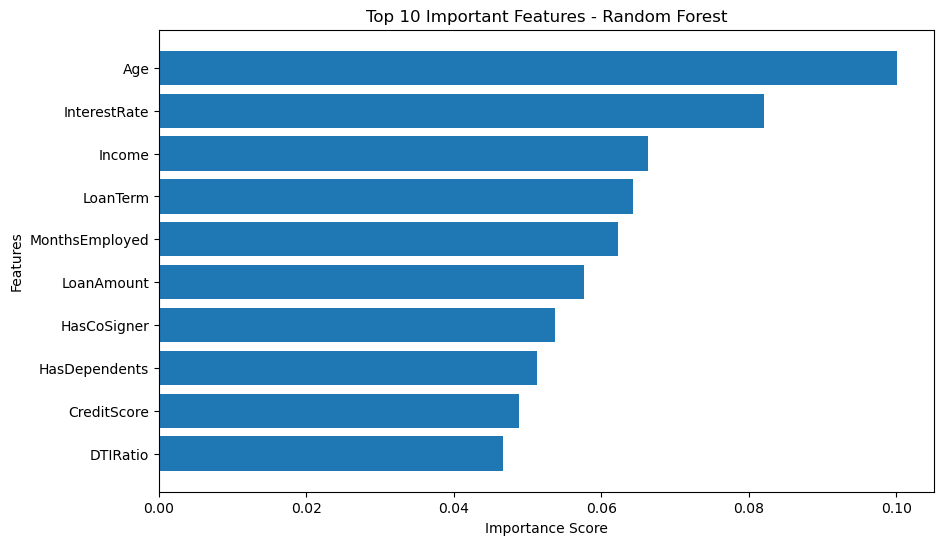

In [93]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Conclusion

In this project, a supervised machine learning pipeline was developed to predict loan defaults using an imbalanced dataset.

The dataset was preprocessed by handling categorical variables through Label Encoding and One-Hot Encoding. The data was then split into training and testing sets, and SMOTE was applied only to the training data to address class imbalance and prevent data leakage.

Two classification models, Logistic Regression and Random Forest, were trained and evaluated using Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC.

Among the two models, Random Forest achieved higher overall Accuracy (87%), Precision (0.31), and ROC-AUC (0.707), while Logistic Regression achieved better Recall for the minority class.

Based on the evaluation metrics, Random Forest was selected as the final model for loan default prediction. The ROC Curve and Feature Importance analysis further demonstrated the model's ability to distinguish between defaulters and non-defaulters and highlighted the most influential features affecting predictions.

This project demonstrates the complete workflow of a supervised machine learning classification problem, including data preprocessing, handling class imbalance, model training, evaluation, and interpretation.